# 02 - Prototyping (JAX)

## GoHREP

**Goal:**

Validate the full technical pipeline by prototyping a JAX-based classification head on top of a frozen ESM-2 encoder, confirming that PHI-base virulence gene sequences can be correctly tokenized, embedded, and classified into 8 functional classes before committing to full LoRA fine-tuning.

**Hypothesis:**

Frozen ESM-2 embeddings, without any fine-tuning, will capture sufficient sequence-level biochemical signal to produce above-chance classification of pathogen virulence genes into functional classes, validating the choice of ESM-2 as the base encoder for this task.

**Rationale:**

Prototyping with a frozen encoder and a lightweight trainable head is a low-cost way to validate the entire pipeline - data loading, tokenization, embedding extraction, gradient flow, and memory constraints - before investing compute in full LoRA fine-tuning. If frozen embeddings already produce meaningfully above-chance performance (random baseline ≈ 12.5% for 8 classes), this provides early evidence that ESM-2's pre-trained representations encode functional class information and that fine-tuning is likely to yield further gains. Any pipeline failures caught here are far cheaper to fix than failures discovered mid fine-tuning.

**Experimental Plan:**

1. **Data loading validation:** Load the saved train/val/test splits from `data/splits/fine_tuning_dataset/`. Verify label mapping, class distributions, and tokenization on a representative batch of PHI-base sequences.
2. **Classification head implementation:** Define an 8-class JAX/Flax classification head on top of frozen ESM-2 embeddings using global average pooling, with progressive dimension reduction and dropout regularisation.
3. **Forward pass validation:** Confirm the pipeline produces output tensors of shape `(batch_size, 8)` and that random initialisation yields approximately uniform class predictions (expected loss ≈ −ln(1/8) ≈ 2.08).
4. **Gradient flow validation:** Compute gradients through the classification head and verify that all parameters receive non-zero gradients of healthy magnitude, confirming the pipeline is ready for training.
5. **Baseline performance:** Train the classification head briefly on frozen embeddings and evaluate on the validation set. Record per-class F1 scores and a confusion matrix as a reference point for comparison against the fine-tuned model.
6. **Memory and performance profiling:** Determine the maximum feasible batch size on Colab A100 for the 150M model and estimate full training duration to inform fine-tuning decisions.

# 0 Environment Setup

This section mounts Google Drive and installs dependencies from the GitHub repository.

In [1]:
import yaml
from google.colab import drive
import os

drive.mount('/content/drive')
PROJECT_ROOT = "/content/drive/MyDrive/esm-phi-effector"
os.chdir(PROJECT_ROOT)

config_path = os.path.join(PROJECT_ROOT, "configs/model_config.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

Mounted at /content/drive


In [2]:
if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 133.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.1/720

In [3]:
import torch
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

## 1 Data Loading Validation

This section loads the curated train/val/test splits saved during data curation, verifies label integrity, and validates that a representative batch of PHI-base sequences tokenizes correctly before building the classification head.

In [4]:
# Load saved splits from data curation
splits_dir = os.path.join(PROJECT_ROOT, config['paths']['splits_dir'], "fine_tuning_dataset")

train_data = torch.load(os.path.join(splits_dir, "train.pt"))
val_data   = torch.load(os.path.join(splits_dir, "val.pt"))
test_data  = torch.load(os.path.join(splits_dir, "test.pt"))

print(f"Train: {len(train_data['sequences'])} sequences")
print(f"Val:   {len(val_data['sequences'])} sequences")
print(f"Test:  {len(test_data['sequences'])} sequences")

# Verify label mapping is consistent with config
print(f"\nLabel mapping: {train_data['label_mapping']}")
assert train_data['label_mapping'] == val_data['label_mapping'] == test_data['label_mapping'], \
    "Label mapping mismatch between splits!"
print("Label mapping consistent across splits: OK")

Train: 3614 sequences
Val:   452 sequences
Test:  452 sequences

Label mapping: {'Effector': 0, 'Transcription factor / Regulator': 1, 'Kinase / Signalling': 2, 'Protease': 3, 'Cell wall / Carbohydrate-active': 4, 'Transporter / Membrane': 5, 'Secondary metabolite / Biosynthesis': 6, 'Secretion system': 7}
Label mapping consistent across splits: OK


In [5]:
# Verify class distributions across splits
import collections

for split_name, split_data in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    counts = collections.Counter(split_data['functional_classes'])
    print(f"\n{split_name} class distribution:")
    for cls, idx in sorted(split_data['label_mapping'].items(), key=lambda x: x[1]):
        print(f"  {cls:<45} {counts[cls]:>5}")


Train class distribution:
  Effector                                        526
  Transcription factor / Regulator               1251
  Kinase / Signalling                             805
  Protease                                        157
  Cell wall / Carbohydrate-active                 221
  Transporter / Membrane                          296
  Secondary metabolite / Biosynthesis             198
  Secretion system                                160

Val class distribution:
  Effector                                         66
  Transcription factor / Regulator                156
  Kinase / Signalling                             101
  Protease                                         20
  Cell wall / Carbohydrate-active                  27
  Transporter / Membrane                           37
  Secondary metabolite / Biosynthesis              25
  Secretion system                                 20

Test class distribution:
  Effector                                         66
  Tr

In [6]:
# Validate tokenization on a small representative batch
model_name = train_data['model']
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Sample a few sequences spanning the length distribution
sample_seqs = train_data['sequences'][:8]
sample_labels = train_data['labels'][:8]
sample_classes = train_data['functional_classes'][:8]

tokens = tokenizer(
    sample_seqs,
    padding=True,
    truncation=True,
    max_length=1024,
    return_tensors="pt"
)

print(f"Tokenization test batch:")
print(f"  Input IDs shape:      {tokens['input_ids'].shape}")
print(f"  Attention mask shape: {tokens['attention_mask'].shape}")
print(f"  Sequence lengths:     {tokens['attention_mask'].sum(dim=1).tolist()}")
print(f"  Labels:               {sample_labels}")
print(f"  Classes:              {sample_classes}")

# Flag any sequences that will be truncated in the full dataset
all_seqs = train_data['sequences'] + val_data['sequences'] + test_data['sequences']
truncated = sum(1 for s in all_seqs if len(s) > 1022)
print(f"\nSequences exceeding 1,022 AA (will be truncated): {truncated} / {len(all_seqs)} ({truncated/len(all_seqs)*100:.1f}%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenization test batch:
  Input IDs shape:      torch.Size([8, 568])
  Attention mask shape: torch.Size([8, 568])
  Sequence lengths:     [455, 554, 246, 476, 257, 568, 460, 384]
  Labels:               [1, 1, 1, 1, 5, 4, 1, 2]
  Classes:              ['Transcription factor / Regulator', 'Transcription factor / Regulator', 'Transcription factor / Regulator', 'Transcription factor / Regulator', 'Transporter / Membrane', 'Cell wall / Carbohydrate-active', 'Transcription factor / Regulator', 'Kinase / Signalling']

Sequences exceeding 1,022 AA (will be truncated): 244 / 4518 (5.4%)


## 2 Classification Head Implementation

This section defines a JAX/Flax classification head on top of the frozen ESM-2 encoder. Global average pooling is used rather than the CLS token to aggregate sequence-level information, which is more appropriate for multi-domain virulence proteins where functional signal is distributed across the full sequence rather than concentrated at a single position.

The attention mask handling is an important addition over the original NLR notebook - without masking, padding tokens contribute to the mean pooling and dilute the signal from real residues, which is particularly problematic for shorter sequences padded to the full 1,024 token length.

In [7]:
import flax.linen as nn
import jax.numpy as jnp

class VirulenceClassifier(nn.Module):
    num_classes: int = 8      # 8 functional classes
    hidden_dim: int = 640     # ESM-2 150M embedding dimension
    layer_1_dim: int = 256
    layer_2_dim: int = 128
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, esm_embeddings, attention_mask=None, training=False):
        # esm_embeddings shape: (batch_size, seq_len, hidden_dim)

        # Global average pooling over sequence length
        # Mask padding tokens to avoid including them in the mean
        if attention_mask is not None:
            mask = attention_mask[:, :, None]  # (batch_size, seq_len, 1)
            sum_embeddings = (esm_embeddings * mask).sum(axis=1)
            lengths = mask.sum(axis=1)
            pooled = sum_embeddings / lengths  # (batch_size, hidden_dim)
        else:
            pooled = jnp.mean(esm_embeddings, axis=1)

        # Classification head with progressive dimension reduction
        x = nn.Dense(self.layer_1_dim)(pooled)
        x = nn.relu(x)
        x = nn.Dropout(self.dropout_rate, deterministic=not training)(x)

        x = nn.Dense(self.layer_2_dim)(x)
        x = nn.relu(x)
        x = nn.Dropout(self.dropout_rate, deterministic=not training)(x)

        # Output layer - 8 functional classes
        logits = nn.Dense(self.num_classes)(x)
        return logits


# Instantiate classifier from config
classifier = VirulenceClassifier(
    num_classes=config['model']['num_classes'],
    hidden_dim=config['model']['hidden_dim'],
    layer_1_dim=config['classification_head']['layer_1_dim'],
    layer_2_dim=config['classification_head']['layer_2_dim'],
    dropout_rate=config['model']['dropout_rate']
)

print("VirulenceClassifier architecture:")
print(f"  Input:    (batch_size, seq_len, {config['model']['hidden_dim']})")
print(f"  Pooled:   (batch_size, {config['model']['hidden_dim']})")
print(f"  Layer 1:  (batch_size, {config['classification_head']['layer_1_dim']})")
print(f"  Layer 2:  (batch_size, {config['classification_head']['layer_2_dim']})")
print(f"  Output:   (batch_size, {config['model']['num_classes']})")

VirulenceClassifier architecture:
  Input:    (batch_size, seq_len, 640)
  Pooled:   (batch_size, 640)
  Layer 1:  (batch_size, 256)
  Layer 2:  (batch_size, 128)
  Output:   (batch_size, 8)


## 3 Forward Pass Validation

This section tests that the full pipeline - ESM-2 embedding extraction followed by classification head inference - produces correctly shaped outputs and that random initialisation yields approximately uniform predictions across all 8 classes. The expected loss at random initialisation is −ln(1/8) ≈ 2.08.

The attention mask is passed through to the classifier here to ensure padding tokens are excluded from mean pooling, consistent with the implementation in section 2. The loss check against −ln(1/8) is a useful sanity check - a large deviation would suggest something is wrong with the initialisation or the label mapping.

In [8]:
# Load ESM-2 encoder (frozen)
model_name = train_data['model']
esm_model = AutoModel.from_pretrained(model_name).eval().to("cuda")

print(f"Loaded: {model_name}")
print(f"Parameters: {sum(p.numel() for p in esm_model.parameters()):,}")
print(f"Device: {next(esm_model.parameters()).device}")

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: facebook/esm2_t30_150M_UR50D
Parameters: 148,138,841
Device: cuda:0


In [9]:
# Extract frozen ESM-2 embeddings for the test batch
with torch.no_grad():
    inputs = {k: v.to("cuda") for k, v in tokens.items()}
    esm_outputs = esm_model(**inputs)
    embeddings = esm_outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)

print(f"ESM-2 embedding shape: {embeddings.shape}")
print(f"Expected:              ({len(sample_seqs)}, 1024, {config['model']['hidden_dim']})")
assert embeddings.shape[-1] == config['model']['hidden_dim'], \
    f"Embedding dim mismatch: got {embeddings.shape[-1]}, expected {config['model']['hidden_dim']}"
print("Embedding shape: OK")

# Convert to JAX arrays for classification head
jax_embeddings = jnp.array(embeddings.cpu().numpy())
jax_mask = jnp.array(tokens['attention_mask'].numpy())

ESM-2 embedding shape: torch.Size([8, 568, 640])
Expected:              (8, 1024, 640)
Embedding shape: OK


In [10]:
# Initialise classifier parameters
key = jax.random.PRNGKey(42)
params = classifier.init(key, jax_embeddings[:1], jax_mask[:1])

# Count trainable parameters in classification head
param_count = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Classification head parameters: {param_count:,}")

# Forward pass on full test batch
logits = classifier.apply(params, jax_embeddings, jax_mask)
print(f"\nOutput logits shape: {logits.shape}")
print(f"Expected:            ({len(sample_seqs)}, {config['model']['num_classes']})")
assert logits.shape == (len(sample_seqs), config['model']['num_classes']), \
    f"Output shape mismatch: got {logits.shape}"
print("Output shape: OK")

Classification head parameters: 198,024

Output logits shape: (8, 8)
Expected:            (8, 8)
Output shape: OK


In [11]:
# Verify random initialisation produces approximately uniform predictions
probs = jax.nn.softmax(logits, axis=-1)
predicted_classes = jnp.argmax(logits, axis=-1)

# Reverse label mapping for readable output
idx_to_class = {v: k for k, v in train_data['label_mapping'].items()}

print("Random initialisation predictions:")
print(f"{'Sequence':<10} {'Predicted class':<45} {'Max prob':<12} {'True class'}")
print("-" * 100)
for i in range(len(sample_seqs)):
    pred_cls = idx_to_class[int(predicted_classes[i])]
    true_cls = sample_classes[i]
    print(f"{i:<10} {pred_cls:<45} {float(probs[i].max()):.4f}      {true_cls}")

# Check initial loss is close to expected random baseline
import optax
labels_jax = jnp.array(sample_labels)
initial_loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels_jax).mean()
expected_random_loss = -jnp.log(1.0 / config['model']['num_classes'])

print(f"\nInitial loss:          {float(initial_loss):.4f}")
print(f"Expected random loss:  {float(expected_random_loss):.4f}  (-ln(1/8))")
print(f"Difference:            {abs(float(initial_loss) - float(expected_random_loss)):.4f}")
print("\nForward pass validation: OK")

Random initialisation predictions:
Sequence   Predicted class                               Max prob     True class
----------------------------------------------------------------------------------------------------
0          Effector                                      0.1574      Transcription factor / Regulator
1          Effector                                      0.1559      Transcription factor / Regulator
2          Effector                                      0.1551      Transcription factor / Regulator
3          Effector                                      0.1682      Transcription factor / Regulator
4          Effector                                      0.1502      Transporter / Membrane
5          Effector                                      0.1586      Cell wall / Carbohydrate-active
6          Kinase / Signalling                           0.1552      Transcription factor / Regulator
7          Effector                                      0.1459      Kinase / Si

## 4 Gradient Flow Validation

This section verifies that gradients flow correctly through the classification head during backpropagation. Healthy gradients confirm the pipeline is ready for training. All parameters should receive non-zero gradients with magnitudes in the range 1e-4 to 1e-1 - values below 1e-6 suggest vanishing gradients, while values above 1 suggest potential instability.

The single optimiser step at the end is a useful addition beyond just checking gradient magnitudes - it confirms the full training loop works end to end and that the loss actually decreases in the right direction, which rules out sign errors or learning rate issues before you commit to full training.

In [12]:
# Define loss function
def cross_entropy_loss(params, embeddings, mask, labels, training=False):
    logits = classifier.apply(params, embeddings, mask, training=training)
    return optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()

# Compute loss and gradients
loss_and_grad_fn = jax.value_and_grad(cross_entropy_loss)
loss_val, grads = loss_and_grad_fn(params, jax_embeddings, jax_mask, labels_jax)

print(f"Loss at random initialisation: {float(loss_val):.4f}")
print(f"Expected random baseline:      {float(expected_random_loss):.4f}")

Loss at random initialisation: 2.1832
Expected random baseline:      2.0794


In [13]:
# Inspect gradient shapes and magnitudes for all parameters
print("\nGradient flow report:")
print(f"{'Parameter':<45} {'Shape':<25} {'Mean |grad|':<15} {'Status'}")
print("-" * 100)

all_healthy = True
for layer, layer_grads in jax.tree_util.tree_leaves_with_path(grads):
    path = ".".join([str(p.key) for p in layer[:-1]])
    grad_array = layer_grads if not isinstance(layer_grads, list) else jax.numpy.array(layer_grads)
    mean_abs = float(jnp.mean(jnp.abs(grad_array)))
    shape = grad_array.shape

    if mean_abs < 1e-6:
        status = "⚠ VANISHING"
        all_healthy = False
    elif mean_abs > 1.0:
        status = "⚠ EXPLODING"
        all_healthy = False
    else:
        status = "✓ OK"

    print(f"{path:<45} {str(shape):<25} {mean_abs:<15.6f} {status}")

print(f"\nAll gradients healthy: {'✓ YES' if all_healthy else '✗ NO - investigate flagged layers'}")


Gradient flow report:
Parameter                                     Shape                     Mean |grad|     Status
----------------------------------------------------------------------------------------------------
params.Dense_0                                (256,)                    0.008839        ✓ OK
params.Dense_0                                (640, 256)                0.000611        ✓ OK
params.Dense_1                                (128,)                    0.016043        ✓ OK
params.Dense_1                                (256, 128)                0.001785        ✓ OK
params.Dense_2                                (8,)                      0.132281        ✓ OK
params.Dense_2                                (128, 8)                  0.009464        ✓ OK

All gradients healthy: ✓ YES


In [14]:
# Verify no parameters have zero gradients (disconnected from computation graph)
zero_grad_params = []
for path, grad in jax.tree_util.tree_leaves_with_path(grads):
    param_path = ".".join([str(p.key) for p in path])
    if jnp.all(grad == 0):
        zero_grad_params.append(param_path)

if zero_grad_params:
    print(f"⚠ Parameters with zero gradients (disconnected from graph):")
    for p in zero_grad_params:
        print(f"  {p}")
else:
    print("✓ No zero-gradient parameters detected")

# Single test optimiser step to confirm training loop works end to end
optimiser = optax.adam(learning_rate=config['training']['learning_rate'])
opt_state = optimiser.init(params)
updates, new_opt_state = optimiser.update(grads, opt_state)
new_params = optax.apply_updates(params, updates)

# Verify loss decreases after one update
new_loss = cross_entropy_loss(new_params, jax_embeddings, jax_mask, labels_jax)
print(f"\nLoss before update: {float(loss_val):.4f}")
print(f"Loss after update:  {float(new_loss):.4f}")
print(f"Loss decreased:     {'✓ YES' if new_loss < loss_val else '✗ NO - check learning rate and gradient signs'}")

✓ No zero-gradient parameters detected

Loss before update: 2.1832
Loss after update:  2.1660
Loss decreased:     ✓ YES


## 5 Baseline Performance

This section trains the classification head on frozen ESM-2 embeddings for a small number of epochs, establishing whether ESM-2's pre-trained representations encode sufficient functional class signal without any encoder fine-tuning. This serves as the lower bound reference for the LoRA fine-tuned model.

- **Random chance:** 12.5% (8 classes)
- **Frozen embeddings + trained head:** measured here
- **LoRA fine-tuned:** measured in notebook 03

In [20]:
# Pre-extract frozen embeddings for all splits to avoid re-computing each epoch
print("Extracting frozen embeddings for all splits...")

print("  Train...")
train_embs, train_masks = extract_embeddings(
    train_data['sequences'], tokenizer, esm_model,
    batch_size=config['training']['batch_size']
)

print("  Val...")
val_embs, val_masks = extract_embeddings(
    val_data['sequences'], tokenizer, esm_model,
    batch_size=config['training']['batch_size']
)

# Concatenate into single arrays
train_embs_np  = np.concatenate([np.pad(e, ((0, 0), (0, max(e.shape[1] for e in train_embs) - e.shape[1]), (0, 0))) for e in train_embs], axis=0)
train_masks_np = np.concatenate([np.pad(m, ((0, 0), (0, max(m.shape[1] for m in train_masks) - m.shape[1]))) for m in train_masks], axis=0)
val_embs_np    = np.concatenate([np.pad(e, ((0, 0), (0, max(e.shape[1] for e in val_embs) - e.shape[1]), (0, 0))) for e in val_embs], axis=0)
val_masks_np   = np.concatenate([np.pad(m, ((0, 0), (0, max(m.shape[1] for m in val_masks) - m.shape[1]))) for m in val_masks], axis=0)

train_labels_np = np.array(train_data['labels'])
val_labels_np   = np.array(val_data['labels'])

print(f"\nTrain embeddings: {train_embs_np.shape}")
print(f"Val embeddings:   {val_embs_np.shape}")

Extracting frozen embeddings for all splits...
  Train...
  Processed 8/3614
  Processed 88/3614
  Processed 168/3614
  Processed 248/3614
  Processed 328/3614
  Processed 408/3614
  Processed 488/3614
  Processed 568/3614
  Processed 648/3614
  Processed 728/3614
  Processed 808/3614
  Processed 888/3614
  Processed 968/3614
  Processed 1048/3614
  Processed 1128/3614
  Processed 1208/3614
  Processed 1288/3614
  Processed 1368/3614
  Processed 1448/3614
  Processed 1528/3614
  Processed 1608/3614
  Processed 1688/3614
  Processed 1768/3614
  Processed 1848/3614
  Processed 1928/3614
  Processed 2008/3614
  Processed 2088/3614
  Processed 2168/3614
  Processed 2248/3614
  Processed 2328/3614
  Processed 2408/3614
  Processed 2488/3614
  Processed 2568/3614
  Processed 2648/3614
  Processed 2728/3614
  Processed 2808/3614
  Processed 2888/3614
  Processed 2968/3614
  Processed 3048/3614
  Processed 3128/3614
  Processed 3208/3614
  Processed 3288/3614
  Processed 3368/3614
  Processed 

In [42]:
# Compute class weights inversely proportional to frequency
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(config['model']['num_classes']),
    y=train_labels_np
)
class_weights_jax = jnp.array(class_weights, dtype=jnp.float32)
print("Class weights:")
for cls, w in zip(train_data['label_mapping'].keys(), class_weights):
    print(f"  {cls:<45} {w:.3f}")

Class weights:
  Effector                                      0.859
  Transcription factor / Regulator              0.361
  Kinase / Signalling                           0.561
  Protease                                      2.877
  Cell wall / Carbohydrate-active               2.044
  Transporter / Membrane                        1.526
  Secondary metabolite / Biosynthesis           2.282
  Secretion system                              2.823


In [43]:
# Initialise fresh classifier parameters and optimiser
key = jax.random.PRNGKey(42)
params = classifier.init(key, jnp.array(train_embs_np[:1]), jnp.array(train_masks_np[:1]))

optimiser = optax.adam(learning_rate=config['training']['learning_rate'])
opt_state = optimiser.init(params)

print("Model reset to random initialisation")

Model reset to random initialisation


In [44]:
# Define JIT-compiled step functions with class weighting
@jax.jit
def train_step(params, opt_state, embeddings, mask, labels, dropout_key):
    def loss_fn(params):
        logits = classifier.apply(
            params, embeddings, mask,
            training=True,
            rngs={'dropout': dropout_key}
        )
        per_sample_loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels)
        sample_weights = class_weights_jax[labels]
        return (per_sample_loss * sample_weights).mean()

    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt_state = optimiser.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

@jax.jit
def eval_step(params, embeddings, mask):
    logits = classifier.apply(params, embeddings, mask, training=False)
    return logits

print("JIT-compiled step functions defined")

JIT-compiled step functions defined


In [45]:
# Training loop with early stopping and class weighting
n_epochs = 50
batch_size = config['training']['batch_size']
n_train = len(train_labels_np)
patience = config['training']['early_stopping_patience']

train_losses, val_accuracies = [], []
best_val_acc = 0
best_params = None
patience_counter = 0
key = jax.random.PRNGKey(42)

print(f"Training classification head on frozen ESM-2 embeddings (patience={patience})...\n")

for epoch in range(n_epochs):
    perm = np.random.permutation(n_train)
    epoch_losses = []

    for i in range(0, n_train, batch_size):
        key, dropout_key = jax.random.split(key)
        idx = perm[i:i + batch_size]
        batch_embs   = jnp.array(train_embs_np[idx])
        batch_masks  = jnp.array(train_masks_np[idx])
        batch_labels = jnp.array(train_labels_np[idx])

        params, opt_state, loss = train_step(
            params, opt_state, batch_embs, batch_masks, batch_labels, dropout_key
        )
        epoch_losses.append(float(loss))

    # Validation accuracy
    val_logits = []
    for i in range(0, len(val_labels_np), batch_size):
        batch_embs  = jnp.array(val_embs_np[i:i + batch_size])
        batch_masks = jnp.array(val_masks_np[i:i + batch_size])
        logits = eval_step(params, batch_embs, batch_masks)
        val_logits.append(np.array(logits))

    val_logits_np = np.concatenate(val_logits, axis=0)
    val_preds     = np.argmax(val_logits_np, axis=1)
    val_acc       = (val_preds == val_labels_np).mean()

    mean_loss = np.mean(epoch_losses)
    train_losses.append(mean_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params
        patience_counter = 0
        improved = "✓"
    else:
        patience_counter += 1
        improved = f"(no improvement {patience_counter}/{patience})"

    print(f"Epoch {epoch+1:>2}/{n_epochs}  |  Loss: {mean_loss:.4f}  |  Val Accuracy: {val_acc*100:.1f}%  {improved}")

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

params = best_params
print(f"\nBest validation accuracy: {best_val_acc*100:.1f}% - weights restored")

Training classification head on frozen ESM-2 embeddings (patience=5)...

Epoch  1/50  |  Loss: 1.9200  |  Val Accuracy: 56.6%  ✓
Epoch  2/50  |  Loss: 1.4788  |  Val Accuracy: 60.4%  ✓
Epoch  3/50  |  Loss: 1.2443  |  Val Accuracy: 66.2%  ✓
Epoch  4/50  |  Loss: 1.1267  |  Val Accuracy: 63.7%  (no improvement 1/5)
Epoch  5/50  |  Loss: 1.0457  |  Val Accuracy: 66.4%  ✓
Epoch  6/50  |  Loss: 0.9823  |  Val Accuracy: 67.0%  ✓
Epoch  7/50  |  Loss: 0.9519  |  Val Accuracy: 67.9%  ✓
Epoch  8/50  |  Loss: 0.9059  |  Val Accuracy: 67.7%  (no improvement 1/5)
Epoch  9/50  |  Loss: 0.8742  |  Val Accuracy: 68.4%  ✓
Epoch 10/50  |  Loss: 0.8610  |  Val Accuracy: 67.5%  (no improvement 1/5)
Epoch 11/50  |  Loss: 0.8312  |  Val Accuracy: 69.2%  ✓
Epoch 12/50  |  Loss: 0.8088  |  Val Accuracy: 69.2%  (no improvement 1/5)
Epoch 13/50  |  Loss: 0.7850  |  Val Accuracy: 70.1%  ✓
Epoch 14/50  |  Loss: 0.7562  |  Val Accuracy: 72.1%  ✓
Epoch 15/50  |  Loss: 0.7362  |  Val Accuracy: 70.1%  (no improveme

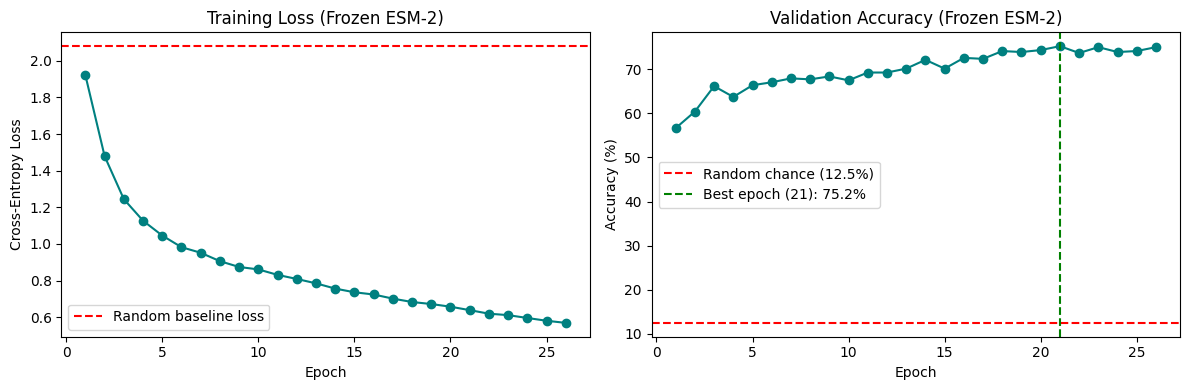

In [46]:
# Plot training curves
epochs_run = len(train_losses)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, epochs_run + 1), train_losses, marker='o', color='teal')
ax1.set_title('Training Loss (Frozen ESM-2)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.axhline(y=float(expected_random_loss), color='red', linestyle='--', label='Random baseline loss')
ax1.legend()

ax2.plot(range(1, epochs_run + 1), [a * 100 for a in val_accuracies], marker='o', color='teal')
ax2.set_title('Validation Accuracy (Frozen ESM-2)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.axhline(y=12.5, color='red', linestyle='--', label='Random chance (12.5%)')
ax2.axvline(x=val_accuracies.index(best_val_acc) + 1, color='green', linestyle='--',
            label=f'Best epoch ({val_accuracies.index(best_val_acc) + 1}): {best_val_acc*100:.1f}%')
ax2.legend()

plt.tight_layout()
plt.show()

Final baseline classification report (frozen ESM-2, trained head, class-weighted loss):
                                     precision    recall  f1-score   support

                           Effector      0.817     0.742     0.778        66
   Transcription factor / Regulator      0.943     0.737     0.827       156
                Kinase / Signalling      0.738     0.752     0.745       101
                           Protease      0.688     0.550     0.611        20
    Cell wall / Carbohydrate-active      0.759     0.815     0.786        27
             Transporter / Membrane      0.596     0.757     0.667        37
Secondary metabolite / Biosynthesis      0.488     0.840     0.618        25
                   Secretion system      0.531     0.850     0.654        20

                           accuracy                          0.750       452
                          macro avg      0.695     0.755     0.711       452
                       weighted avg      0.784     0.750     0.

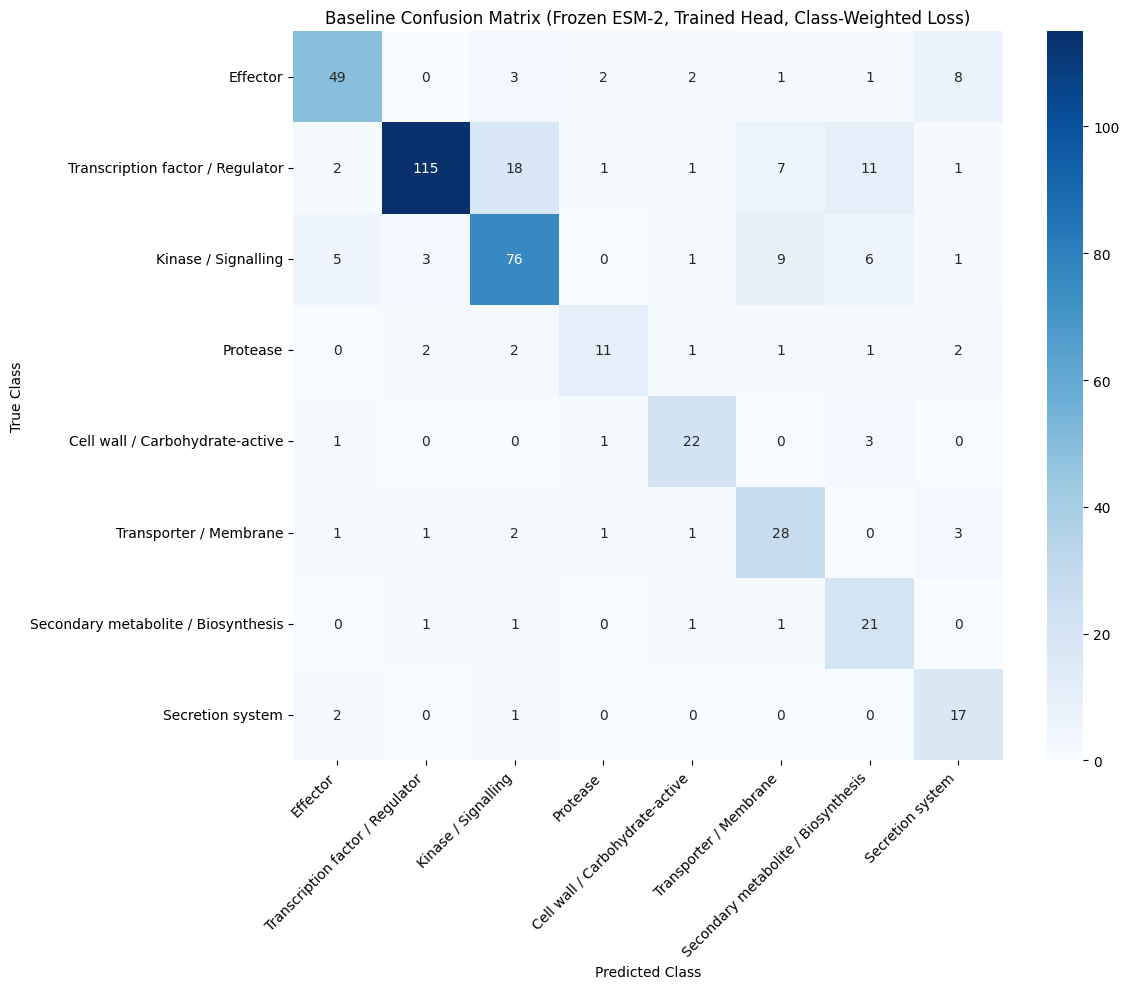


Baseline Summary:
  Random chance:                              12.5%
  Frozen ESM-2 + trained head (weighted):    75.2%

LoRA fine-tuning target should significantly exceed this.


In [48]:
# Final evaluation
idx_to_class = {v: k for k, v in train_data['label_mapping'].items()}
class_names = [idx_to_class[i] for i in range(config['model']['num_classes'])]

print("Final baseline classification report (frozen ESM-2, trained head, class-weighted loss):")
print(classification_report(val_labels_np, val_preds, target_names=class_names, digits=3))

fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(val_labels_np, val_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_title('Baseline Confusion Matrix (Frozen ESM-2, Trained Head, Class-Weighted Loss)')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nBaseline Summary:")
print(f"  Random chance:                              12.5%")
print(f"  Frozen ESM-2 + trained head (weighted):    {best_val_acc*100:.1f}%")
print(f"\nLoRA fine-tuning target should significantly exceed this.")

Were the misclassified sequences the truncated ones? They lose some information when they are truncated.

In [54]:
# Analyse whether truncated sequences are more likely to be misclassified
all_val_seqs = val_data['sequences']
all_val_labels = val_labels_np
all_val_preds = val_preds  # from the last evaluation

seq_lengths = np.array([len(s) for s in all_val_seqs])
correct = (all_val_preds == all_val_labels)
truncated = seq_lengths > 1022

print(f"Validation sequences exceeding 1,022 AA (truncated): {truncated.sum()} / {len(truncated)} ({truncated.mean()*100:.1f}%)")
print(f"\nAccuracy on truncated sequences:     {correct[truncated].mean()*100:.1f}%")
print(f"Accuracy on non-truncated sequences: {correct[~truncated].mean()*100:.1f}%")

Validation sequences exceeding 1,022 AA (truncated): 25 / 452 (5.5%)

Accuracy on truncated sequences:     80.0%
Accuracy on non-truncated sequences: 74.7%


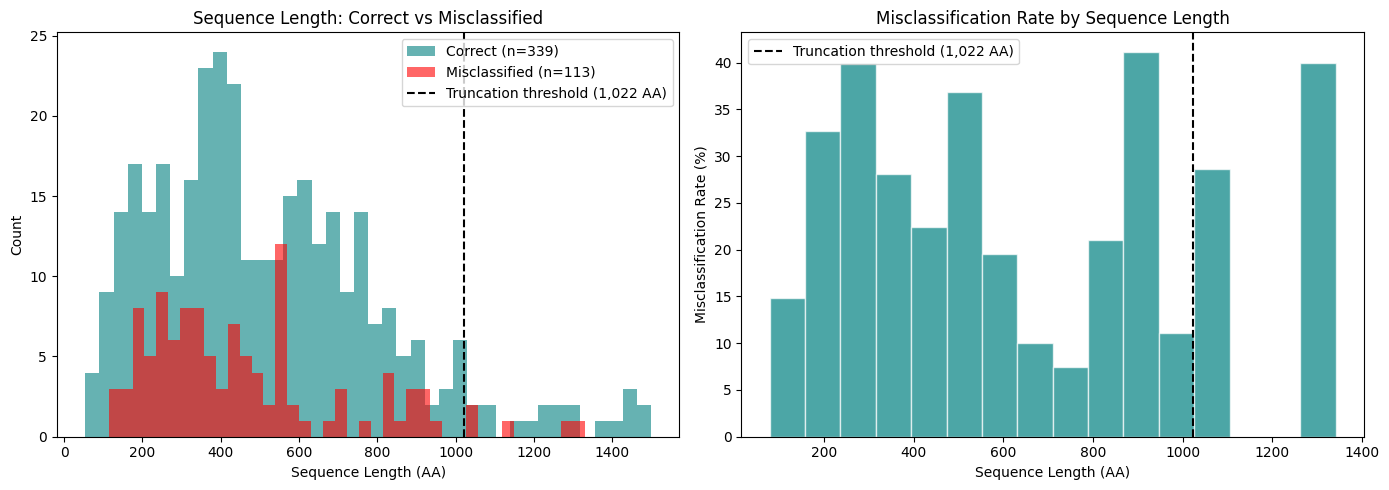

In [55]:
# Plot sequence length distributions for correct vs misclassified
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histograms
axes[0].hist(seq_lengths[correct], bins=40, alpha=0.6, color='teal', label=f'Correct (n={correct.sum()})')
axes[0].hist(seq_lengths[~correct], bins=40, alpha=0.6, color='red', label=f'Misclassified (n={(~correct).sum()})')
axes[0].axvline(x=1022, color='black', linestyle='--', label='Truncation threshold (1,022 AA)')
axes[0].set_title('Sequence Length: Correct vs Misclassified')
axes[0].set_xlabel('Sequence Length (AA)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: misclassification rate by length bin
bin_edges = np.linspace(0, seq_lengths.max(), 20)
bin_indices = np.digitize(seq_lengths, bin_edges)
bin_error_rates = []
bin_centres = []
bin_counts = []

for b in range(1, len(bin_edges)):
    mask = bin_indices == b
    if mask.sum() >= 5:  # only plot bins with enough sequences
        bin_error_rates.append((~correct[mask]).mean() * 100)
        bin_centres.append((bin_edges[b-1] + bin_edges[b]) / 2)
        bin_counts.append(mask.sum())

axes[1].bar(bin_centres, bin_error_rates, width=bin_edges[1]-bin_edges[0],
            color='teal', alpha=0.7, edgecolor='white')
axes[1].axvline(x=1022, color='black', linestyle='--', label='Truncation threshold (1,022 AA)')
axes[1].set_title('Misclassification Rate by Sequence Length')
axes[1].set_xlabel('Sequence Length (AA)')
axes[1].set_ylabel('Misclassification Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

Is the second best prediction correct?

In [56]:
# Extract top-2 predictions for all validation sequences
all_val_logits = []
for i in range(0, len(val_labels_np), batch_size):
    batch_embs  = jnp.array(val_embs_np[i:i + batch_size])
    batch_masks = jnp.array(val_masks_np[i:i + batch_size])
    logits = eval_step(params, batch_embs, batch_masks)
    all_val_logits.append(np.array(logits))

all_val_logits = np.concatenate(all_val_logits, axis=0)

# Get top-2 predictions
top2_preds = np.argsort(all_val_logits, axis=1)[:, ::-1][:, :2]
top1_preds = top2_preds[:, 0]
top2_preds_only = top2_preds[:, 1]

# Analysis
correct_top1 = (top1_preds == val_labels_np)
correct_top2 = (top2_preds_only == val_labels_np)
correct_top1_or_top2 = correct_top1 | correct_top2

print(f"Top-1 accuracy:                    {correct_top1.mean()*100:.1f}%")
print(f"Top-2 accuracy (either correct):   {correct_top1_or_top2.mean()*100:.1f}%")
print(f"\nOf the {(~correct_top1).sum()} misclassified sequences:")
print(f"  2nd guess was correct:   {correct_top2[~correct_top1].sum()} ({correct_top2[~correct_top1].mean()*100:.1f}%)")
print(f"  2nd guess was wrong:     {(~correct_top2[~correct_top1]).sum()} ({(~correct_top2[~correct_top1]).mean()*100:.1f}%)")
print(f"  Random chance (1 in 7):  14.3%")

Top-1 accuracy:                    75.2%
Top-2 accuracy (either correct):   85.8%

Of the 112 misclassified sequences:
  2nd guess was correct:   48 (42.9%)
  2nd guess was wrong:     64 (57.1%)
  Random chance (1 in 7):  14.3%


Cluster embeddings with PCA and colour by class

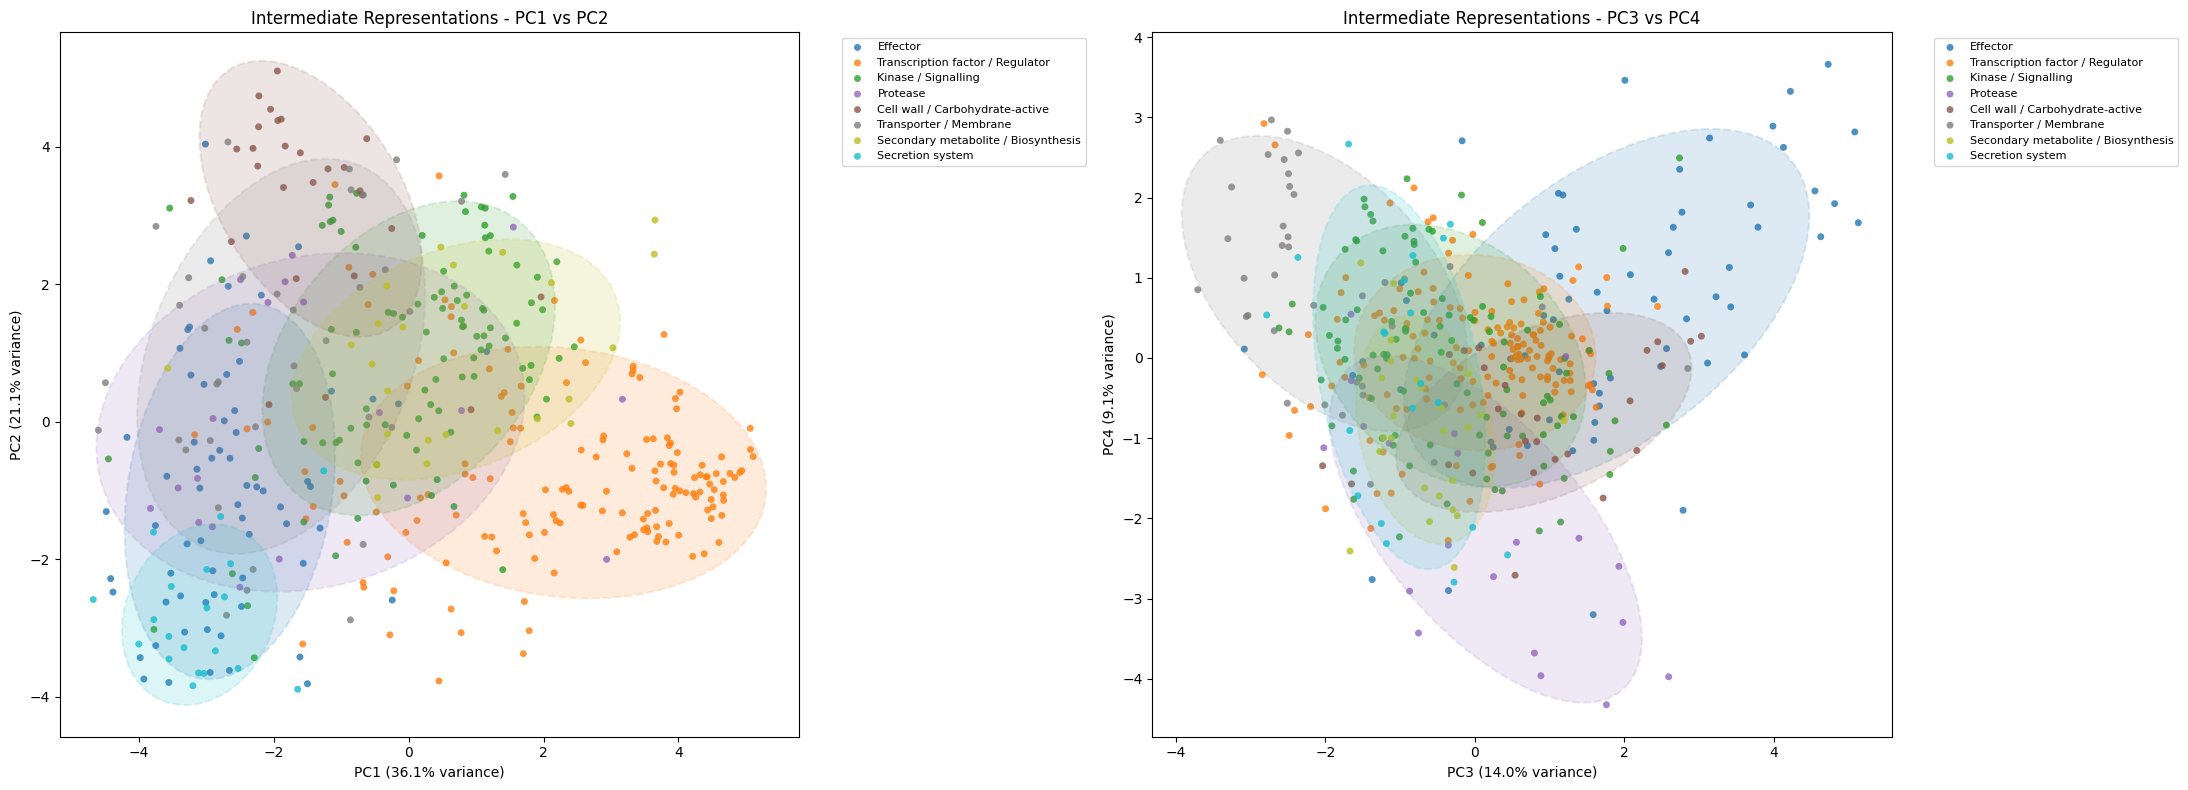

Variance explained:
  PC1: 36.1%
  PC2: 21.1%
  PC3: 14.0%
  PC4: 9.1%
  Total (PC1-4): 80.2%


In [66]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

class VirulenceClassifierIntermediate(nn.Module):
    num_classes: int = 8
    hidden_dim: int = 640
    layer_1_dim: int = 256
    layer_2_dim: int = 128
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, esm_embeddings, attention_mask=None, training=False):
        if attention_mask is not None:
            mask = attention_mask[:, :, None]
            sum_embeddings = (esm_embeddings * mask).sum(axis=1)
            lengths = mask.sum(axis=1)
            pooled = sum_embeddings / lengths
        else:
            pooled = jnp.mean(esm_embeddings, axis=1)

        x = nn.Dense(self.layer_1_dim)(pooled)
        x = nn.relu(x)
        x = nn.Dense(self.layer_2_dim)(x)
        x = nn.relu(x)
        return x  # return intermediate representation, not logits

intermediate_model = VirulenceClassifierIntermediate(
    num_classes=config['model']['num_classes'],
    hidden_dim=config['model']['hidden_dim'],
    layer_1_dim=config['classification_head']['layer_1_dim'],
    layer_2_dim=config['classification_head']['layer_2_dim'],
    dropout_rate=config['model']['dropout_rate']
)

# Extract intermediate representations using the trained params
val_intermediate = []
for i in range(0, len(val_labels_np), batch_size):
    batch_embs  = jnp.array(val_embs_np[i:i + batch_size])
    batch_masks = jnp.array(val_masks_np[i:i + batch_size])
    intermediate = intermediate_model.apply(params, batch_embs, batch_masks)
    val_intermediate.append(np.array(intermediate))

val_intermediate_np = np.concatenate(val_intermediate, axis=0)

def plot_confidence_ellipse(x, y, ax, color, n_std=1.5, alpha=0.15):
    """Plot a covariance ellipse for a set of 2D points."""
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse(
        (0, 0), width=rx * 2, height=ry * 2,
        facecolor=color, alpha=alpha, edgecolor=color,
        linewidth=1.5, linestyle='--'
    )
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

# PCA with PC1 and PC2
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Rerun PCA with 4 components to get PC3 and PC4
pca_4 = PCA(n_components=4)
val_intermediate_pca4 = pca_4.fit_transform(val_intermediate_np)

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (2, 3)]):
    for cls_idx in range(config['model']['num_classes']):
        mask = val_labels_np == cls_idx
        color = colors[cls_idx]
        x = val_intermediate_pca4[mask, pc_x]
        y = val_intermediate_pca4[mask, pc_y]

        ax.scatter(x, y, c=[color], label=idx_to_class[cls_idx],
                   alpha=0.8, s=25, edgecolors='none')
        plot_confidence_ellipse(x, y, ax, color=color, n_std=1.5, alpha=0.15)

    ax.set_title(f'Intermediate Representations - PC{pc_x+1} vs PC{pc_y+1}')
    ax.set_xlabel(f'PC{pc_x+1} ({pca_4.explained_variance_ratio_[pc_x]*100:.1f}% variance)')
    ax.set_ylabel(f'PC{pc_y+1} ({pca_4.explained_variance_ratio_[pc_y]*100:.1f}% variance)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print(f"Variance explained:")
for i, var in enumerate(pca_4.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")
print(f"  Total (PC1-4): {pca_4.explained_variance_ratio_.sum()*100:.1f}%")

## 6 Memory and Performance Profiling

This section determines the maximum feasible batch size for the 150M ESM-2 model on Colab hardware and estimates full training duration. This informs batch size selection for LoRA fine-tuning in notebook 03.

In [49]:
import time

# Memory monitoring utility
def get_gpu_memory():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved  = torch.cuda.memory_reserved() / 1024**3
        total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
        return allocated, reserved, total
    return None

allocated, reserved, total = get_gpu_memory()
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Total memory:     {total:.1f} GB")
print(f"Currently allocated: {allocated:.2f} GB")
print(f"Currently reserved:  {reserved:.2f} GB")
print(f"Available:           {total - reserved:.2f} GB")

GPU: NVIDIA A100-SXM4-40GB
Total memory:     39.5 GB
Currently allocated: 0.62 GB
Currently reserved:  1.86 GB
Available:           37.63 GB


In [50]:
# Profile forward pass at different batch sizes
print("Batch size profiling (forward pass through frozen ESM-2):\n")
print(f"{'Batch size':<15} {'Time (s)':<15} {'GPU mem used (GB)':<25} {'Status'}")
print("-" * 70)

test_batch_sizes = config['memory']['test_batch_sizes']
feasible_batch_sizes = []

for bs in test_batch_sizes:
    try:
        # Create a batch of max-length sequences
        dummy_seqs = ["A" * 1022] * bs
        tokens = tokenizer(
            dummy_seqs,
            padding=True,
            truncation=True,
            max_length=1024,
            return_tensors="pt"
        )

        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        start = time.time()

        with torch.no_grad():
            inputs = {k: v.to("cuda") for k, v in tokens.items()}
            outputs = esm_model(**inputs)

        torch.cuda.synchronize()
        elapsed = time.time() - start
        peak_mem = torch.cuda.max_memory_allocated() / 1024**3

        feasible_batch_sizes.append(bs)
        print(f"{bs:<15} {elapsed:<15.3f} {peak_mem:<25.2f} ✓ OK")

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"{bs:<15} {'N/A':<15} {'N/A':<25} ✗ OOM")
            torch.cuda.empty_cache()
        else:
            raise e

Batch size profiling (forward pass through frozen ESM-2):

Batch size      Time (s)        GPU mem used (GB)         Status
----------------------------------------------------------------------
2               0.078           0.72                      ✓ OK
4               0.127           0.78                      ✓ OK
8               0.223           0.98                      ✓ OK
16              0.437           1.38                      ✓ OK


In [51]:
# Profile a full training step at the recommended batch size
recommended_bs = feasible_batch_sizes[-1]  # largest feasible
print(f"\nFull training step profiling at batch size {recommended_bs}:\n")

# Time a forward + backward pass through the classification head
sample_embs   = jnp.array(train_embs_np[:recommended_bs])
sample_masks  = jnp.array(train_masks_np[:recommended_bs])
sample_labels = jnp.array(train_labels_np[:recommended_bs])

# Warmup
_, _, _ = train_step(params, opt_state, sample_embs, sample_masks, sample_labels,
                     jax.random.PRNGKey(0))

# Timed runs
n_timed = 10
times = []
for i in range(n_timed):
    key, dropout_key = jax.random.split(key)
    start = time.time()
    _, _, _ = train_step(params, opt_state, sample_embs, sample_masks, sample_labels,
                         dropout_key)
    jax.effects_barrier()  # ensure JAX async ops complete before timing
    times.append(time.time() - start)

mean_step_time = np.mean(times)
steps_per_epoch = len(train_labels_np) // recommended_bs
estimated_epoch_time = mean_step_time * steps_per_epoch

print(f"Mean step time:         {mean_step_time*1000:.1f} ms")
print(f"Steps per epoch:        {steps_per_epoch}")
print(f"Estimated epoch time:   {estimated_epoch_time:.1f} s ({estimated_epoch_time/60:.1f} min)")
print(f"Estimated 50 epochs:    {50 * estimated_epoch_time / 60:.1f} min")


Full training step profiling at batch size 16:

Mean step time:         0.3 ms
Steps per epoch:        225
Estimated epoch time:   0.1 s (0.0 min)
Estimated 50 epochs:    0.1 min


In [53]:
# Summary
print("\nMemory and Performance Profiling Summary:")
print("-" * 50)
print(f"GPU:                    {torch.cuda.get_device_name(0)}")
print(f"Feasible batch sizes:   {feasible_batch_sizes}")
print(f"Recommended batch size: {recommended_bs}")
print(f"Mean step time:         {mean_step_time*1000:.1f} ms")
print(f"Estimated epoch time:   {estimated_epoch_time:.1f} s")
print(f"\nRecommended config for notebook 03 (LoRA fine-tuning):")
print(f"  batch_size: {recommended_bs}")
print(f"  class_weighting: True")
print(f"  Note: LoRA fine-tuning will be slower than frozen embedding training")
print(f"  as gradients must flow through the ESM-2 encoder layers")


Memory and Performance Profiling Summary:
--------------------------------------------------
GPU:                    NVIDIA A100-SXM4-40GB
Feasible batch sizes:   [2, 4, 8, 16]
Recommended batch size: 16
Mean step time:         0.3 ms
Estimated epoch time:   0.1 s

Recommended config for notebook 03 (LoRA fine-tuning):
  batch_size: 16
  class_weighting: True
  Note: LoRA fine-tuning will be slower than frozen embedding training
  as gradients must flow through the ESM-2 encoder layers
